# Attrition Rate Prediction

### Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Reading

In [4]:
adv = pd.read_excel(r"C:\Users\USER\Downloads\HR-Employee Dataset.xlsx")
adv.head()

,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,emp no,Employee Number,Gender,Job Role,...,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
0,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-1,1,Female,Sales Executive,...,3,1,80,0,8,1,6,4,0,5
1,No,Travel_Frequently,45 - 54,Current Employees,R&D,Life Sciences,STAFF-2,2,Male,Research Scientist,...,4,4,80,1,10,3,10,7,1,7
2,Yes,Travel_Rarely,35 - 44,Ex-Employees,R&D,Other,STAFF-4,4,Male,Laboratory Technician,...,3,2,80,0,7,3,0,0,0,0
3,No,Travel_Frequently,25 - 34,Current Employees,R&D,Life Sciences,STAFF-5,5,Female,Research Scientist,...,3,3,80,0,8,3,8,7,3,0
4,No,Travel_Rarely,25 - 34,Current Employees,R&D,Medical,STAFF-7,7,Male,Laboratory Technician,...,3,4,80,1,6,3,2,2,2,2


In [5]:
adv.shape

(1470, 44)

In [6]:
# checking for null values
adv.isnull().sum()

Attrition                        0
Business Travel                  0
CF_age band                      0
CF_attrition label               0
Department                       0
Education Field                  0
emp no                           0
Employee Number                  0
Gender                           0
Job Role                         0
Marital Status                   0
Over Time                        0
Over18                           0
Training Times Last Year         0
-2                               0
0                                0
Age                              0
CF_attrition count               0
CF_attrition counts           1233
CF_attrition rate                0
CF_current Employee              0
Daily Rate                       0
Distance From Home               0
Education                        0
Employee Count                   0
Environment Satisfaction         0
Hourly Rate                      0
Job Involvement                  0
Job Level           

### Data Cleaning

In [7]:
drop_cols = ['Employee Number', 'emp no', 'CF_attrition count', 
             'CF_attrition counts', 'CF_attrition rate', 
             'CF_current Employee', '-2', '0', 'Over18', 'Employee Count', 'Standard Hours']
adv = adv.drop(columns=drop_cols, errors='ignore')

In [8]:
adv.shape

(1470, 33)

In [9]:
adv.isnull().sum()

Attrition                     0
Business Travel               0
CF_age band                   0
CF_attrition label            0
Department                    0
Education Field               0
Gender                        0
Job Role                      0
Marital Status                0
Over Time                     0
Training Times Last Year      0
Age                           0
Daily Rate                    0
Distance From Home            0
Education                     0
Environment Satisfaction      0
Hourly Rate                   0
Job Involvement               0
Job Level                     0
Job Satisfaction              0
Monthly Income                0
Monthly Rate                  0
Num Companies Worked          0
Percent Salary Hike           0
Performance Rating            0
Relationship Satisfaction     0
Stock Option Level            0
Total Working Years           0
Work Life Balance             0
Years At Company              0
Years In Current Role         0
Years Si

In [10]:
for i in adv.columns:
 print(i,':','\n',adv[i].unique())

Attrition : 
 ['Yes' 'No']
Business Travel : 
 ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
CF_age band : 
 ['35 - 44' '45 - 54' '25 - 34' 'Over 55' 'Under 25']
CF_attrition label : 
 ['Ex-Employees' 'Current Employees']
Department : 
 ['Sales' 'R&D' 'HR']
Education Field : 
 ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Gender : 
 ['Female' 'Male']
Job Role : 
 ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
Marital Status : 
 ['Single' 'Married' 'Divorced']
Over Time : 
 ['Yes' 'No']
Training Times Last Year : 
 [0 3 2 5 1 4 6]
Age : 
 [41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]
Daily Rate : 
 [1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  39

In [11]:
adv.dtypes

Attrition                     object
Business Travel               object
CF_age band                   object
CF_attrition label            object
Department                    object
Education Field               object
Gender                        object
Job Role                      object
Marital Status                object
Over Time                     object
Training Times Last Year       int64
Age                            int64
Daily Rate                     int64
Distance From Home             int64
Education                     object
Environment Satisfaction       int64
Hourly Rate                    int64
Job Involvement                int64
Job Level                      int64
Job Satisfaction               int64
Monthly Income                 int64
Monthly Rate                   int64
Num Companies Worked           int64
Percent Salary Hike            int64
Performance Rating             int64
Relationship Satisfaction      int64
Stock Option Level             int64
T

## Data Analysis

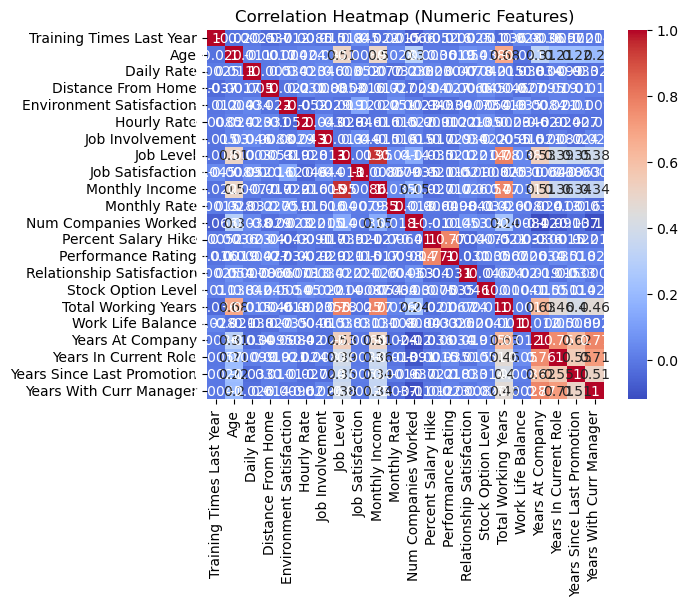

In [62]:
# Heat map
numeric_adv = adv.select_dtypes(include=['int64'])
sns.heatmap(numeric_adv.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

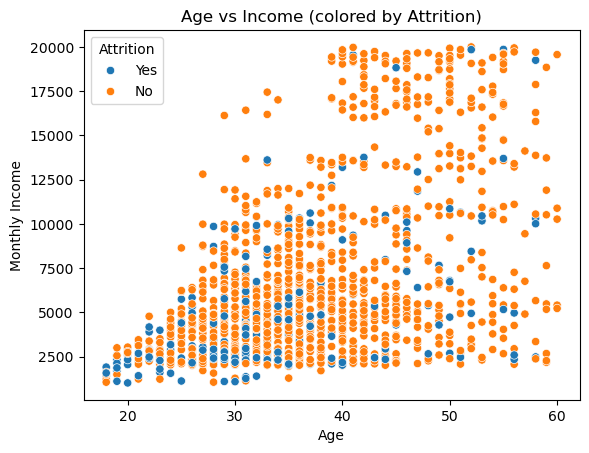

In [12]:
sns.scatterplot(x=adv['Age'], y=adv['Monthly Income'], hue=adv['Attrition'])
plt.title("Age vs Income (colored by Attrition)")
plt.show()

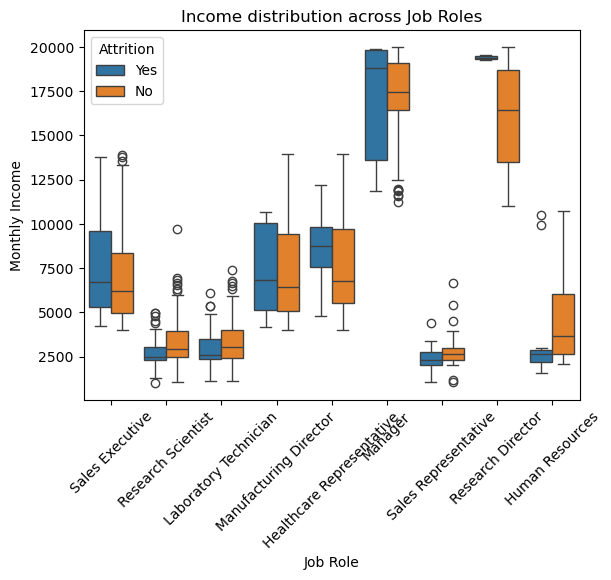

In [13]:
sns.boxplot(x=adv['Job Role'], y=adv['Monthly Income'], hue=adv['Attrition'])
plt.xticks(rotation=45)
plt.title("Income distribution across Job Roles")
plt.show()

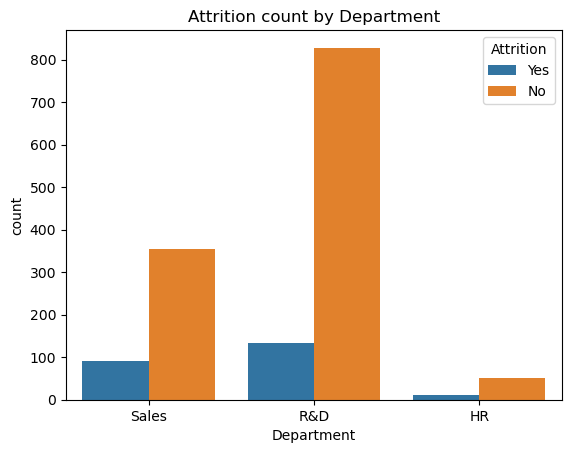

In [14]:
sns.countplot(x=adv['Department'], hue=adv['Attrition'])
plt.title("Attrition count by Department")
plt.show()

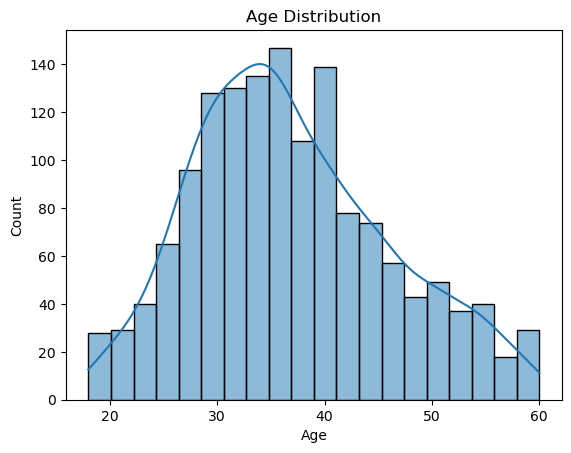

In [15]:
sns.histplot(adv['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

In [ ]:
# sns.pairplot(adv,hue='Attrition')
# plt.show()

In [38]:
obj_cols = adv.select_dtypes(include=['object']).columns
for col in obj_cols:
    print(col, ":\n", adv[col].unique())

Attrition :
 ['Yes' 'No']
Business Travel :
 ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
CF_age band :
 ['35 - 44' '45 - 54' '25 - 34' 'Over 55' 'Under 25']
CF_attrition label :
 ['Ex-Employees' 'Current Employees']
Department :
 ['Sales' 'R&D' 'HR']
Education Field :
 ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Gender :
 ['Female' 'Male']
Job Role :
 ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
Marital Status :
 ['Single' 'Married' 'Divorced']
Over Time :
 ['Yes' 'No']
Education :
 ['Associates Degree' 'High School' "Master's Degree" "Bachelor's Degree"
 'Doctoral Degree']


### Encoding

In [52]:
from sklearn.preprocessing import LabelEncoder
binary_cols = ['Attrition', 'Over Time', 'Gender', 'CF_attrition label']
le = LabelEncoder()
for col in binary_cols:
    adv[col] = le.fit_transform(adv[col])

In [53]:
adv.head()

,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,Gender,Job Role,Marital Status,Over Time,...,Percent Salary Hike,Performance Rating,Relationship Satisfaction,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
0,1,Travel_Rarely,35 - 44,1,Sales,Life Sciences,0,Sales Executive,Single,1,...,11,3,1,0,8,1,6,4,0,5
1,0,Travel_Frequently,45 - 54,0,R&D,Life Sciences,1,Research Scientist,Married,0,...,23,4,4,1,10,3,10,7,1,7
2,1,Travel_Rarely,35 - 44,1,R&D,Other,1,Laboratory Technician,Single,1,...,15,3,2,0,7,3,0,0,0,0
3,0,Travel_Frequently,25 - 34,0,R&D,Life Sciences,0,Research Scientist,Married,1,...,11,3,3,0,8,3,8,7,3,0
4,0,Travel_Rarely,25 - 34,0,R&D,Medical,1,Laboratory Technician,Married,0,...,12,3,4,1,6,3,2,2,2,2


In [54]:
adv = pd.get_dummies(adv, columns=['Job Role', 'Department', 'Business Travel', 
                                 'Marital Status', 'Education Field', 'CF_age band'], drop_first=True)

In [55]:
adv['Education'] = adv['Education'].map({
    'High School': 1, 
    'Associates Degree': 2,
    "Bachelor's Degree": 3, 
    "Master's Degree": 4, 
    "Doctoral Degree": 5
})

In [56]:
adv.head()

,Attrition,CF_attrition label,Gender,Over Time,Training Times Last Year,Age,Daily Rate,Distance From Home,Education,Environment Satisfaction,...,Marital Status_Single,Education Field_Life Sciences,Education Field_Marketing,Education Field_Medical,Education Field_Other,Education Field_Technical Degree,CF_age band_35 - 44,CF_age band_45 - 54,CF_age band_Over 55,CF_age band_Under 25
0,1,1,0,1,0,41,1102,1,2,2,...,True,True,False,False,False,False,True,False,False,False
1,0,0,1,0,3,49,279,8,1,3,...,False,True,False,False,False,False,False,True,False,False
2,1,1,1,1,3,37,1373,2,2,4,...,True,False,False,False,True,False,True,False,False,False
3,0,0,0,1,3,33,1392,3,4,4,...,False,True,False,False,False,False,False,False,False,False
4,0,0,1,0,3,27,591,2,1,1,...,False,False,False,True,False,False,False,False,False,False


In [57]:
for i in adv.columns:
 print(i,':','\n',adv[i].unique())

Attrition : 
 [1 0]
CF_attrition label : 
 [1 0]
Gender : 
 [0 1]
Over Time : 
 [1 0]
Training Times Last Year : 
 [0 3 2 5 1 4 6]
Age : 
 [41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]
Daily Rate : 
 [1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705  924 1459  125  895  813 1273  869  890  852 1141  464 1240
 1357  994  721 1360 1065  408 1211 1229  626 1434 1488 1097 1443  515
  853 1142  655 1115  427  653  989 1435 1223  836 1195 1339  664  318
 1225 1328 1082  548  132  746  776  193  397  945 1214  111  573 1153
 1400  541  432  288  669  530  632 1334  638 1093 1217 1353  120  682
  489  807  827  871  665 1040 1420  240 1280  534 1456  658  142 1127
 1031 1189 1354 1467  922  394 1312  750  441  684  249  841  147  528
  594  470  957  542  802 1355 1150 1329  959 1033 1316  364  438  689
  20

In [58]:
adv.dtypes

Attrition                            int32
CF_attrition label                   int32
Gender                               int32
Over Time                            int32
Training Times Last Year             int64
Age                                  int64
Daily Rate                           int64
Distance From Home                   int64
Education                            int64
Environment Satisfaction             int64
Hourly Rate                          int64
Job Involvement                      int64
Job Level                            int64
Job Satisfaction                     int64
Monthly Income                       int64
Monthly Rate                         int64
Num Companies Worked                 int64
Percent Salary Hike                  int64
Performance Rating                   int64
Relationship Satisfaction            int64
Stock Option Level                   int64
Total Working Years                  int64
Work Life Balance                    int64
Years At Co

In [61]:
# Converting the boolean columns to integer
bool_cols = adv.select_dtypes(include="bool").columns
adv[bool_cols] = adv[bool_cols].astype(int)

In [62]:
adv.dtypes

Attrition                            int32
CF_attrition label                   int32
Gender                               int32
Over Time                            int32
Training Times Last Year             int64
Age                                  int64
Daily Rate                           int64
Distance From Home                   int64
Education                            int64
Environment Satisfaction             int64
Hourly Rate                          int64
Job Involvement                      int64
Job Level                            int64
Job Satisfaction                     int64
Monthly Income                       int64
Monthly Rate                         int64
Num Companies Worked                 int64
Percent Salary Hike                  int64
Performance Rating                   int64
Relationship Satisfaction            int64
Stock Option Level                   int64
Total Working Years                  int64
Work Life Balance                    int64
Years At Co

### ip and op creation

In [74]:
ip = adv.drop(columns=["Attrition", "CF_attrition label"],axis=1)
op = adv.Attrition

In [75]:
ip.head()

,Gender,Over Time,Training Times Last Year,Age,Daily Rate,Distance From Home,Education,Environment Satisfaction,Hourly Rate,Job Involvement,...,Marital Status_Single,Education Field_Life Sciences,Education Field_Marketing,Education Field_Medical,Education Field_Other,Education Field_Technical Degree,CF_age band_35 - 44,CF_age band_45 - 54,CF_age band_Over 55,CF_age band_Under 25
0,0,1,0,41,1102,1,2,2,94,3,...,1,1,0,0,0,0,1,0,0,0
1,1,0,3,49,279,8,1,3,61,2,...,0,1,0,0,0,0,0,1,0,0
2,1,1,3,37,1373,2,2,4,92,2,...,1,0,0,0,1,0,1,0,0,0
3,0,1,3,33,1392,3,4,4,56,3,...,0,1,0,0,0,0,0,0,0,0
4,1,0,3,27,591,2,1,1,40,3,...,0,0,0,1,0,0,0,0,0,0


In [76]:
op.head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int32

### Train test split

In [77]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(ip,op,test_size=0.2)

### Standard Scaler

In [78]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

## Machine Learning Model

In [79]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

### Prediction

In [80]:
y1 = lr.predict(x_test)

## Accuracy

In [81]:
 from sklearn.metrics import f1_score,recall_score,precision_score,accuracy_score
 acc = accuracy_score(y1,y_test)
 f1 = f1_score(y1,y_test)
 pre = precision_score(y1,y_test)
 rel = recall_score(y1,y_test)
 print('Accuracy :',acc)
 print('f1_score :',f1)
 print('precision :',pre)
 print('Recall :',rel)

Accuracy : 0.8605442176870748
f1_score : 0.5287356321839081
precision : 0.3770491803278688
Recall : 0.8846153846153846


In [82]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(y1,y_test)
cm

array([[230,  38],
       [  3,  23]], dtype=int64)

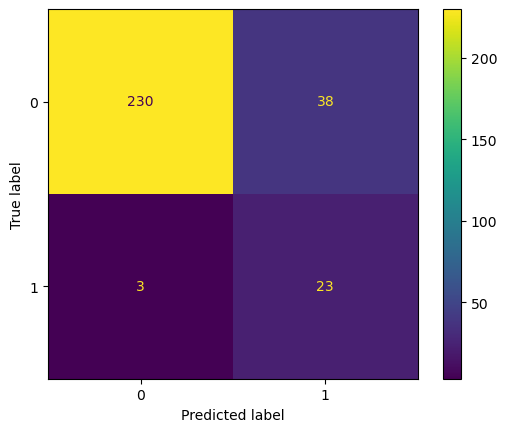

In [83]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()